## Predicting Chocolate Bar Ratings

Data source: https://www.kaggle.com/datasets/rtatman/chocolate-bar-ratings

### Importing Libraries

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf

In [2]:
data = pd.read_csv('archive/flavors_of_cacao.csv')
data

,Company \n(Maker-if known),Specific Bean Origin\nor Bar Name,REF,Review\nDate,Cocoa\nPercent,Company\nLocation,Rating,Bean\nType,Broad Bean\nOrigin
0,A. Morin,Agua Grande,1876,2016,63%,France,3.75,,Sao Tome
1,A. Morin,Kpime,1676,2015,70%,France,2.75,,Togo
2,A. Morin,Atsane,1676,2015,70%,France,3.00,,Togo
3,A. Morin,Akata,1680,2015,70%,France,3.50,,Togo
4,A. Morin,Quilla,1704,2015,70%,France,3.50,,Peru
...,...,...,...,...,...,...,...,...,...
1790,Zotter,Peru,647,2011,70%,Austria,3.75,,Peru
1791,Zotter,Congo,749,2011,65%,Austria,3.00,Forastero,Congo
1792,Zotter,Kerala State,749,2011,65%,Austria,3.50,Forastero,India
1793,Zotter,Kerala State,781,2011,62%,Austria,3.25,,India


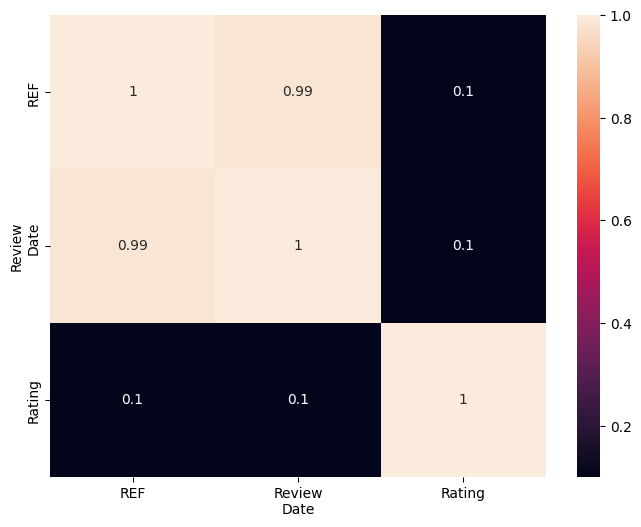

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()

In [8]:
data.drop(['REF', 'Review\nDate'], axis=1, inplace=True)

In [9]:
data

,Company \n(Maker-if known),Specific Bean Origin\nor Bar Name,Cocoa\nPercent,Company\nLocation,Rating,Bean\nType,Broad Bean\nOrigin
0,A. Morin,Agua Grande,63%,France,3.75,,Sao Tome
1,A. Morin,Kpime,70%,France,2.75,,Togo
2,A. Morin,Atsane,70%,France,3.00,,Togo
3,A. Morin,Akata,70%,France,3.50,,Togo
4,A. Morin,Quilla,70%,France,3.50,,Peru
...,...,...,...,...,...,...,...
1790,Zotter,Peru,70%,Austria,3.75,,Peru
1791,Zotter,Congo,65%,Austria,3.00,Forastero,Congo
1792,Zotter,Kerala State,65%,Austria,3.50,Forastero,India
1793,Zotter,Kerala State,62%,Austria,3.25,,India


### Preprocessing

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1795 entries, 0 to 1794
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Company 
(Maker-if known)         1795 non-null   object 
 1   Specific Bean Origin
or Bar Name  1795 non-null   object 
 2   Cocoa
Percent                     1795 non-null   object 
 3   Company
Location                  1795 non-null   object 
 4   Rating                            1795 non-null   float64
 5   Bean
Type                         1794 non-null   object 
 6   Broad Bean
Origin                 1794 non-null   object 
dtypes: float64(1), object(6)
memory usage: 98.3+ KB


In [12]:
data.isnull().sum()

Company \n(Maker-if known)           0
Specific Bean Origin\nor Bar Name    0
Cocoa\nPercent                       0
Company\nLocation                    0
Rating                               0
Bean\nType                           1
Broad Bean\nOrigin                   1
dtype: int64

In [13]:
data = data.dropna(axis=0).reset_index(drop=True)

In [14]:
data.isna().sum()

Company \n(Maker-if known)           0
Specific Bean Origin\nor Bar Name    0
Cocoa\nPercent                       0
Company\nLocation                    0
Rating                               0
Bean\nType                           0
Broad Bean\nOrigin                   0
dtype: int64

In [15]:
data.dtypes

Company \n(Maker-if known)            object
Specific Bean Origin\nor Bar Name     object
Cocoa\nPercent                        object
Company\nLocation                     object
Rating                               float64
Bean\nType                            object
Broad Bean\nOrigin                    object
dtype: object

In [16]:
def remove_percents(df):
    return df.apply(lambda x: float(x.strip('%')) / 100)

In [17]:
data.columns = ['Company', 'Specific Origin', 'Cocoa Percent', 'Location', 'Rating', 'Bean Type', 'Broad Origin']

In [19]:
data['Cocoa Percent'] = remove_percents(data['Cocoa Percent'])

In [21]:
len(data['Specific Origin'].unique())

1038

In [22]:
categorical_features = ['Company', 'Specific Origin', 'Location', 'Bean Type', 'Broad Origin']

In [23]:
def onehot_encode(df, columns):
    df = df.copy()
    for column in columns:
        dummies = pd.get_dummies(df[column], dtype=int, prefix=column)
        df = pd.concat([df, dummies], axis=1)
        df = df.drop(column, axis=1)
    return df

In [24]:
data = onehot_encode(data, categorical_features)

In [25]:
data

,Cocoa Percent,Rating,Company_A. Morin,Company_AMMA,Company_Acalli,Company_Adi,Company_Aequare (Gianduja),Company_Ah Cacao,Company_Akesson's (Pralus),Company_Alain Ducasse,...,Broad Origin_Venezuela,"Broad Origin_Venezuela, Carribean","Broad Origin_Venezuela, Dom. Rep.","Broad Origin_Venezuela, Ghana","Broad Origin_Venezuela, Java","Broad Origin_Venezuela, Trinidad",Broad Origin_Venezuela/ Ghana,Broad Origin_Vietnam,Broad Origin_West Africa,Broad Origin_
0,0.63,3.75,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.70,2.75,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.70,3.00,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0.70,3.50,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0.70,3.50,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1788,0.70,3.75,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1789,0.65,3.00,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1790,0.65,3.50,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1791,0.62,3.25,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
y = data['Rating'].copy()
X = data.drop('Rating', axis=1).copy()

In [27]:
y

0       3.75
1       2.75
2       3.00
3       3.50
4       3.50
        ... 
1788    3.75
1789    3.00
1790    3.50
1791    3.25
1792    3.00
Name: Rating, Length: 1793, dtype: float64

In [28]:
X

,Cocoa Percent,Company_A. Morin,Company_AMMA,Company_Acalli,Company_Adi,Company_Aequare (Gianduja),Company_Ah Cacao,Company_Akesson's (Pralus),Company_Alain Ducasse,Company_Alexandre,...,Broad Origin_Venezuela,"Broad Origin_Venezuela, Carribean","Broad Origin_Venezuela, Dom. Rep.","Broad Origin_Venezuela, Ghana","Broad Origin_Venezuela, Java","Broad Origin_Venezuela, Trinidad",Broad Origin_Venezuela/ Ghana,Broad Origin_Vietnam,Broad Origin_West Africa,Broad Origin_
0,0.63,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.70,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.70,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0.70,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0.70,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1788,0.70,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1789,0.65,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1790,0.65,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1791,0.62,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
scaler = MinMaxScaler()

X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

In [31]:
X

,Cocoa Percent,Company_A. Morin,Company_AMMA,Company_Acalli,Company_Adi,Company_Aequare (Gianduja),Company_Ah Cacao,Company_Akesson's (Pralus),Company_Alain Ducasse,Company_Alexandre,...,Broad Origin_Venezuela,"Broad Origin_Venezuela, Carribean","Broad Origin_Venezuela, Dom. Rep.","Broad Origin_Venezuela, Ghana","Broad Origin_Venezuela, Java","Broad Origin_Venezuela, Trinidad",Broad Origin_Venezuela/ Ghana,Broad Origin_Vietnam,Broad Origin_West Africa,Broad Origin_
0,0.362069,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.482759,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.482759,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.482759,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.482759,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1788,0.482759,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1789,0.396552,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1790,0.396552,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1791,0.344828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Training

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True, random_state=1)

In [35]:
X_train.shape

(1255, 1655)

In [37]:
inputs = tf.keras.Input(shape=(X_train.shape[1], ))
x = tf.keras.layers.Dense(16, activation='relu')(inputs)
x = tf.keras.layers.Dense(16, activation='relu')(x)
outputs = tf.keras.layers.Dense(1)(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

optimizer = tf.keras.optimizers.RMSprop(0.001)

model.compile(
    optimizer=optimizer,
    loss='mse'
)

In [38]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 1655)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 16)                  │          26,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 16)                  │             272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,785 (104.63 KB)

 Trainable params: 26,785 (104.63 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
epochs = 50
batch_size = 32

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=epochs,
    batch_size=batch_size
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 8.2936 - val_loss: 6.3453
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.4313 - val_loss: 2.6486
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.4071 - val_loss: 0.5759
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3887 - val_loss: 0.3012
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2802 - val_loss: 0.2544
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2317 - val_loss: 0.2391
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2002 - val_loss: 0.2304
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1744 - val_loss: 0.2293
Epoch 9/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1545 - val_loss: 0.2352
Epoch 10/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1399 - val_loss: 0.2314
Epoch 11/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1260 - val_loss: 0.2311
Epoch 12/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1148 - val_

In [41]:
history.history['loss']

[8.293641090393066,
 4.431343078613281,
 1.40713632106781,
 0.38872969150543213,
 0.2801867425441742,
 0.2317429780960083,
 0.20019745826721191,
 0.17435774207115173,
 0.15450114011764526,
 0.1399158239364624,
 0.12600088119506836,
 0.11478998512029648,
 0.10382280498743057,
 0.09467419236898422,
 0.0870901346206665,
 0.0802052840590477,
 0.07381154596805573,
 0.06889273971319199,
 0.0642080008983612,
 0.059614889323711395,
 0.0560993030667305,
 0.05432344973087311,
 0.050446704030036926,
 0.04869379475712776,
 0.04589064419269562,
 0.0442662313580513,
 0.04262562468647957,
 0.0412147156894207,
 0.04009541496634483,
 0.03852294757962227,
 0.03750709444284439,
 0.03664008900523186,
 0.03713541477918625,
 0.03624039143323898,
 0.034057557582855225,
 0.03437099978327751,
 0.0338006354868412,
 0.03338813781738281,
 0.032111477106809616,
 0.03243110328912735,
 0.032173920422792435,
 0.031177395954728127,
 0.030146798118948936,
 0.030490214005112648,
 0.03016335517168045,
 0.0292655956000089

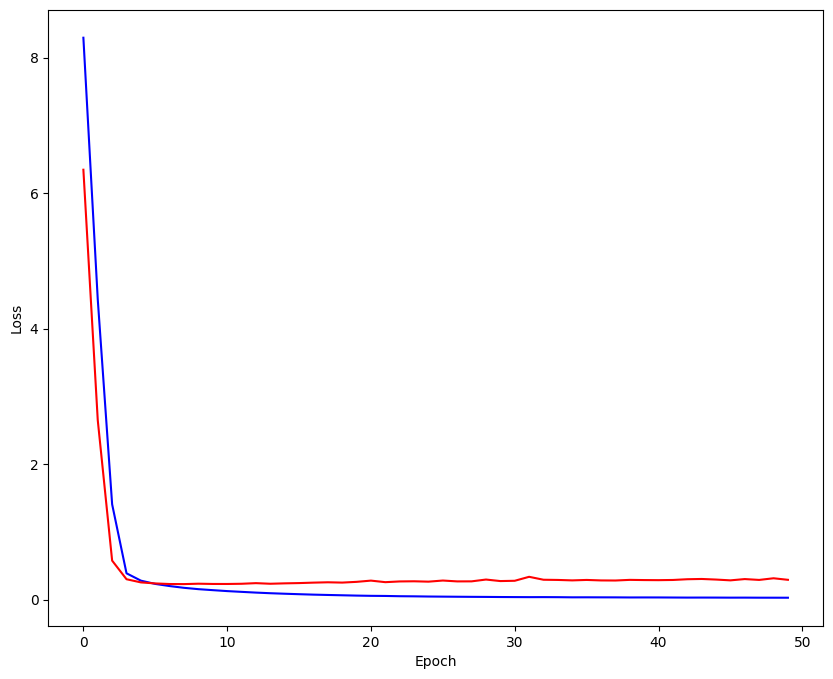

In [42]:
plt.figure(figsize=(10,8))
plt.plot(range(epochs), history.history['loss'], c='blue')
plt.plot(range(epochs), history.history['val_loss'], c='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [43]:
np.argmin(history.history['val_loss'])

np.int64(7)

In [44]:
model.evaluate(X_test, y_test)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3137


0.3137461841106415